In [170]:
import os
import re
from pathlib import Path
from io import StringIO

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.weightstats import ttest_ind






In [3]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'

In [19]:
output_dir = Path('../data/spatial/plots')


## knockdown efficiency

In [239]:
df = pd.read_csv(StringIO("""disease	cell_line	gene	type	value
breast	ETCC-006	MGP	NC	1
breast	ETCC-006	MGP	NC	0.935487007
breast	ETCC-006	MGP	NC	1.053307282
breast	ETCC-006	MGP	KD	0.628909952
breast	ETCC-006	MGP	KD	0.615410032
breast	ETCC-006	MGP	KD	0.55972471
breast	ETCC-006	PLAT	NC	1
breast	ETCC-006	PLAT	NC	0.844109871
breast	ETCC-006	PLAT	NC	0.954727409
breast	ETCC-006	PLAT	KD	0.545144594
breast	ETCC-006	PLAT	KD	0.598175635
breast	ETCC-006	PLAT	KD	0.58322647
breast	ETCC-010	MGP	NC	1
breast	ETCC-010	MGP	NC	1.014669635
breast	ETCC-010	MGP	NC	0.993062882
breast	ETCC-010	MGP	KD	0.612313657
breast	ETCC-010	MGP	KD	0.521293673
breast	ETCC-010	MGP	KD	0.553831887
breast	ETCC-010	PLAT	NC	0.994827329
breast	ETCC-010	PLAT	NC	0.892743896
breast	ETCC-010	PLAT	NC	1.112428775
breast	ETCC-010	PLAT	KD	0.584687601
breast	ETCC-010	PLAT	KD	0.521112985
breast	ETCC-010	PLAT	KD	0.533350249"""), sep='\t')
df

,disease,cell_line,gene,type,value
0,breast,ETCC-006,MGP,NC,1.000000
1,breast,ETCC-006,MGP,NC,0.935487
2,breast,ETCC-006,MGP,NC,1.053307
3,breast,ETCC-006,MGP,KD,0.628910
4,breast,ETCC-006,MGP,KD,0.615410
5,breast,ETCC-006,MGP,KD,0.559725
6,breast,ETCC-006,PLAT,NC,1.000000
7,breast,ETCC-006,PLAT,NC,0.844110
8,breast,ETCC-006,PLAT,NC,0.954727
9,breast,ETCC-006,PLAT,KD,0.545145


In [240]:
def normalize_to_controls(df):
    f = df[df['type'] == 'NC']
    ctrl_values = f[['cell_line', 'gene', 'value']].groupby(['cell_line', 'gene']).mean()
    
    df['value'] = [val / ctrl_values.loc[(ct, g), 'value'] * 100
                   for ct, g, val in df[['cell_line', 'gene', 'value']].values]
    return df
    
    

In [241]:
df = normalize_to_controls(df)

In [242]:
def get_kd_stats(df):
    data = []
    for cl in set(df['cell_line']):
        for gene in set(df['gene']):
            f = df[(
                (df['cell_line'] == cl) &\
                (df['gene'] == gene)
            )]
            xs = f[f['type'] == 'KD']['value'].values
            ys = f[f['type'] == 'NC']['value'].values
            _, pval, _ = ttest_ind(xs, ys)
            print(cl, gene, xs, ys, pval)
            data.append([cl, gene, round(pval, 6)])
    stat_df = pd.DataFrame(data, columns=['cell_line', 'gene', 'p-value'])
    stat_df = stat_df.sort_values(['cell_line', 'gene'])
    return stat_df

In [243]:
get_kd_stats(df)

ETCC-006 PLAT [58.43261392 64.1168716  62.51450995] [107.18736746  90.47791492 102.33471762] 0.0018659007417561452
ETCC-006 MGP [63.12678872 61.77173527 56.1823253 ] [100.37492413  93.89943735 105.72563852] 0.0005966799230536047
ETCC-010 PLAT [58.4687601 52.1112985 53.3350249] [ 99.4827329  89.2743896 111.2428775] 0.0024000652687273544
ETCC-010 MGP [61.07394725 51.99534899 55.24080521] [ 99.74291208 101.20610419  99.05098373] 8.760837296600265e-05


,cell_line,gene,p-value
1,ETCC-006,MGP,0.000597
0,ETCC-006,PLAT,0.001866
3,ETCC-010,MGP,0.000088
2,ETCC-010,PLAT,0.002400


In [244]:
def plot_kd(df):
    for cl in set(df['cell_line']):
        source = df[df['cell_line'] == cl]

        sns.barplot(data=source, x='gene', y='value', hue='type', errorbar='se')
        plt.title(cl)
        plt.savefig(output_dir / f'functional_kd_{cl}.svg')
        plt.show()

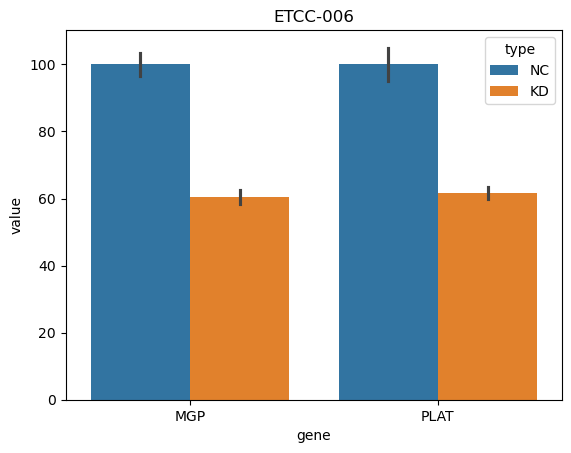

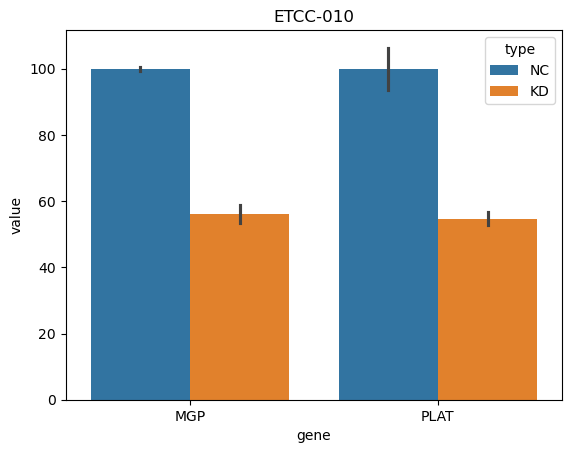

In [245]:
plot_kd(df)

In [247]:
df = pd.read_csv(StringIO("""disease	cell_line	gene	type	value
prostate	PC-3	GDF15	NC	1
prostate	PC-3	GDF15	NC	1.15367269
prostate	PC-3	GDF15	NC	1.15713815
prostate	PC-3	GDF15	KD	0.32001131
prostate	PC-3	GDF15	KD	0.13227272
prostate	PC-3	GDF15	KD	0.22441418
prostate	PC-3	ALDH1A3	NC	1
prostate	PC-3	ALDH1A3	NC	0.789832
prostate	PC-3	ALDH1A3	NC	1.050026
prostate	PC-3	ALDH1A3	KD	0.45714
prostate	PC-3	ALDH1A3	KD	0.468033
prostate	PC-3	ALDH1A3	KD	0.458175
prostate	PC-3	FASN	NC	1
prostate	PC-3	FASN	NC	0.933709
prostate	PC-3	FASN	NC	0.99743
prostate	PC-3	FASN	KD	0.525164
prostate	PC-3	FASN	KD	0.552315
prostate	PC-3	FASN	KD	0.48156
prostate	PC-3	ANPEP	NC	1
prostate	PC-3	ANPEP	NC	0.948069
prostate	PC-3	ANPEP	NC	1.074193
prostate	PC-3	ANPEP	KD	0.402102
prostate	PC-3	ANPEP	KD	0.412715
prostate	PC-3	ANPEP	KD	0.45595"""), sep='\t')
df

,disease,cell_line,gene,type,value
0,prostate,PC-3,GDF15,NC,1.000000
1,prostate,PC-3,GDF15,NC,1.153673
2,prostate,PC-3,GDF15,NC,1.157138
3,prostate,PC-3,GDF15,KD,0.320011
4,prostate,PC-3,GDF15,KD,0.132273
5,prostate,PC-3,GDF15,KD,0.224414
6,prostate,PC-3,ALDH1A3,NC,1.000000
7,prostate,PC-3,ALDH1A3,NC,0.789832
8,prostate,PC-3,ALDH1A3,NC,1.050026
9,prostate,PC-3,ALDH1A3,KD,0.457140


In [248]:
df = normalize_to_controls(df)

In [249]:
get_kd_stats(df)

PC-3 ANPEP [39.91401143 40.96749388 45.25914696] [ 99.2633994   94.10855181 106.62804879] 0.0001298375088514621
PC-3 GDF15 [28.99694294 11.98552799 20.33467246] [ 90.6122441 104.5368714 104.8508845] 0.0003041185418539882
PC-3 FASN [53.75016333 56.52904895 49.28732482] [102.34929152  95.56445464 102.08625384] 0.00010672135800125673
PC-3 ALDH1A3 [48.29185121 49.44257776 48.40118767] [105.63908477  83.4371296  110.92378563] 0.003687440997552348


,cell_line,gene,p-value
3,PC-3,ALDH1A3,0.003687
0,PC-3,ANPEP,0.000130
2,PC-3,FASN,0.000107
1,PC-3,GDF15,0.000304


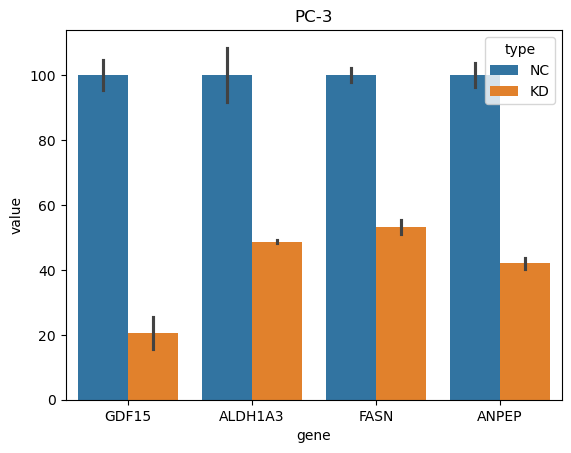

In [250]:
plot_kd(df)

In [252]:
output_dir.absolute()

PosixPath('/storage1/fs1/dinglab/Active/Projects/estorrs/3d-analysis/notebooks/../data/spatial/plots')

## proliferation

In [210]:
df = pd.read_csv(StringIO("""disease	cell_line	gene	replicate	time	value
breast	ETCC-006	NC	1	0	0.2150816
breast	ETCC-006	NC	1	24	0.3451955
breast	ETCC-006	NC	1	48	0.5441982
breast	ETCC-006	NC	1	72	0.756667
breast	ETCC-006	NC	1	96	1.07892595
breast	ETCC-006	NC	1	120	1.311608
breast	ETCC-006	NC	2	0	0.2190528
breast	ETCC-006	NC	2	24	0.338941
breast	ETCC-006	NC	2	48	0.565949
breast	ETCC-006	NC	2	72	0.8143908
breast	ETCC-006	NC	2	96	1.0663124
breast	ETCC-006	NC	2	120	1.300887
breast	ETCC-006	NC	3	0	0.2244979
breast	ETCC-006	NC	3	24	0.3446236
breast	ETCC-006	NC	3	48	0.5897905
breast	ETCC-006	NC	3	72	0.7878633
breast	ETCC-006	NC	3	96	1.082593
breast	ETCC-006	NC	3	120	1.267251
breast	ETCC-006	MGP	1	0	0.2005203
breast	ETCC-006	MGP	1	24	0.5043596
breast	ETCC-006	MGP	1	48	0.8289575
breast	ETCC-006	MGP	1	72	1.1545151
breast	ETCC-006	MGP	1	96	1.5817164
breast	ETCC-006	MGP	1	120	1.948604
breast	ETCC-006	MGP	2	0	0.2009803
breast	ETCC-006	MGP	2	24	0.5156124
breast	ETCC-006	MGP	2	48	0.849886
breast	ETCC-006	MGP	2	72	1.1702548
breast	ETCC-006	MGP	2	96	1.5640268
breast	ETCC-006	MGP	2	120	1.9738783
breast	ETCC-006	MGP	3	0	0.2494117
breast	ETCC-006	MGP	3	24	0.5058715
breast	ETCC-006	MGP	3	48	0.8518714
breast	ETCC-006	MGP	3	72	1.16550904
breast	ETCC-006	MGP	3	96	1.6160666
breast	ETCC-006	MGP	3	120	1.9287201
breast	ETCC-006	PLAT	1	0	0.2210069
breast	ETCC-006	PLAT	1	24	0.5204268
breast	ETCC-006	PLAT	1	48	0.8446362
breast	ETCC-006	PLAT	1	72	1.15683919
breast	ETCC-006	PLAT	1	96	1.6440565
breast	ETCC-006	PLAT	1	120	1.901256
breast	ETCC-006	PLAT	2	0	0.2240048
breast	ETCC-006	PLAT	2	24	0.5014734
breast	ETCC-006	PLAT	2	48	0.8246735
breast	ETCC-006	PLAT	2	72	1.1577295
breast	ETCC-006	PLAT	2	96	1.5510483
breast	ETCC-006	PLAT	2	120	1.921283
breast	ETCC-006	PLAT	3	0	0.2012398
breast	ETCC-006	PLAT	3	24	0.5158937
breast	ETCC-006	PLAT	3	48	0.8708662
breast	ETCC-006	PLAT	3	72	1.2061837
breast	ETCC-006	PLAT	3	96	1.5492928
breast	ETCC-006	PLAT	3	120	1.933762
breast	ETCC-010	NC	1	0	0.2096514
breast	ETCC-010	NC	1	24	0.3445725
breast	ETCC-010	NC	1	48	0.5487711
breast	ETCC-010	NC	1	72	0.818395
breast	ETCC-010	NC	1	96	1.043469
breast	ETCC-010	NC	1	120	1.218299
breast	ETCC-010	NC	2	0	0.19075
breast	ETCC-010	NC	2	24	0.3228849
breast	ETCC-010	NC	2	48	0.561309
breast	ETCC-010	NC	2	72	0.8345092
breast	ETCC-010	NC	2	96	1.000983
breast	ETCC-010	NC	2	120	1.2822644
breast	ETCC-010	NC	3	0	0.1925756
breast	ETCC-010	NC	3	24	0.3238569
breast	ETCC-010	NC	3	48	0.5516055
breast	ETCC-010	NC	3	72	0.8668817
breast	ETCC-010	NC	3	96	1.102755
breast	ETCC-010	NC	3	120	1.273548
breast	ETCC-010	MGP	1	0	0.203723
breast	ETCC-010	MGP	1	24	0.4706808
breast	ETCC-010	MGP	1	48	0.821221
breast	ETCC-010	MGP	1	72	1.2477861
breast	ETCC-010	MGP	1	96	1.54099798
breast	ETCC-010	MGP	1	120	1.878576
breast	ETCC-010	MGP	2	0	0.1826431
breast	ETCC-010	MGP	2	24	0.492774
breast	ETCC-010	MGP	2	48	0.8554113
breast	ETCC-010	MGP	2	72	1.2318161
breast	ETCC-010	MGP	2	96	1.58288901
breast	ETCC-010	MGP	2	120	1.918409
breast	ETCC-010	MGP	3	0	0.2191653
breast	ETCC-010	MGP	3	24	0.467217
breast	ETCC-010	MGP	3	48	0.8352824
breast	ETCC-010	MGP	3	72	1.2208778
breast	ETCC-010	MGP	3	96	1.6050843
breast	ETCC-010	MGP	3	120	1.939818
breast	ETCC-010	PLAT	1	0	0.2064362
breast	ETCC-010	PLAT	1	24	0.5006479
breast	ETCC-010	PLAT	1	48	0.8271025
breast	ETCC-010	PLAT	1	72	1.3173691
breast	ETCC-010	PLAT	1	96	1.5635621
breast	ETCC-010	PLAT	1	120	1.922789
breast	ETCC-010	PLAT	2	0	0.1992338
breast	ETCC-010	PLAT	2	24	0.4870613
breast	ETCC-010	PLAT	2	48	0.8655922
breast	ETCC-010	PLAT	2	72	1.3242917
breast	ETCC-010	PLAT	2	96	1.5187225
breast	ETCC-010	PLAT	2	120	1.90484
breast	ETCC-010	PLAT	3	0	0.2118308
breast	ETCC-010	PLAT	3	24	0.462339
breast	ETCC-010	PLAT	3	48	0.852553
breast	ETCC-010	PLAT	3	72	1.2742195
breast	ETCC-010	PLAT	3	96	1.6051655
breast	ETCC-010	PLAT	3	120	1.9058541"""), sep='\t')
df

,disease,cell_line,gene,replicate,time,value
0,breast,ETCC-006,NC,1,0,0.215082
1,breast,ETCC-006,NC,1,24,0.345195
2,breast,ETCC-006,NC,1,48,0.544198
3,breast,ETCC-006,NC,1,72,0.756667
4,breast,ETCC-006,NC,1,96,1.078926
...,...,...,...,...,...,...
103,breast,ETCC-010,PLAT,3,24,0.462339
104,breast,ETCC-010,PLAT,3,48,0.852553
105,breast,ETCC-010,PLAT,3,72,1.274220
106,breast,ETCC-010,PLAT,3,96,1.605166


In [211]:
def get_proliferation_stats(df):
    data = []
    for time in set(df['time']):
        for cl in set(df['cell_line']):
            f = df[(
                (df['time'] == time) &\
                (df['cell_line'] == cl)
            )]
            for gene in set(f['gene']):
                xs = f[f['gene'] == gene]['value'].values
                ys = f[f['gene'] == 'NC']['value'].values
                _, pval, _ = ttest_ind(xs, ys)
                if gene != 'NC':
                    data.append([cl, time, gene, round(pval, 6)])
    stat_df = pd.DataFrame(data, columns=['cell_line', 'time', 'gene', 'p-value'])
    stat_df = stat_df.sort_values(['cell_line', 'gene', 'time'])
    return stat_df

In [212]:
get_proliferation_stats(df)


,cell_line,time,gene,p-value
1,ETCC-006,0,MGP,0.883262
17,ETCC-006,24,MGP,0.000002
13,ETCC-006,48,MGP,0.000052
9,ETCC-006,72,MGP,0.000026
5,ETCC-006,96,MGP,0.000006
21,ETCC-006,120,MGP,0.000004
0,ETCC-006,0,PLAT,0.617974
16,ETCC-006,24,PLAT,0.000010
12,ETCC-006,48,PLAT,0.000117
8,ETCC-006,72,PLAT,0.000077


In [64]:
def plot_proliferation(df):
    for cl in set(df['cell_line']):
        source = df[df['cell_line'] == cl].copy()
        mask = (
            (source['time'] == 0) &\
            (source['gene'] == 'NC')
        )
        mean = source[mask]['value'].values.mean()
        source['value'] /= mean
        source['value'] *= 100

        sns.barplot(source, x='time', y='value', hue='gene', errorbar='se')
        plt.title(cl)
        plt.savefig(output_dir / f'functional_proliferation_{cl}.svg')
        plt.show()

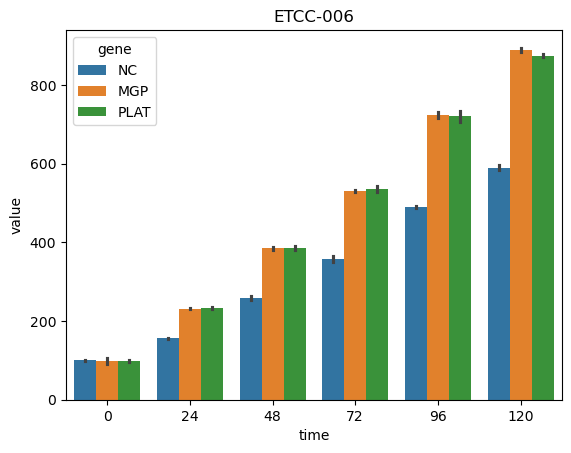

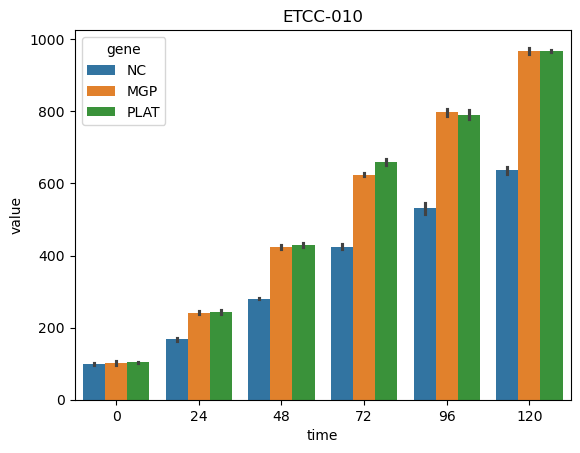

In [65]:
plot_proliferation(df)

In [195]:
df = pd.read_csv(StringIO("""disease	cell_line	gene	replicate	time	value
prostate	PC-3	NC	1	0	0.417
prostate	PC-3	NC	1	24	0.513
prostate	PC-3	NC	1	48	1.112
prostate	PC-3	NC	1	72	1.577
prostate	PC-3	NC	1	96	1.773813
prostate	PC-3	NC	1	120	1.73975
prostate	PC-3	NC	2	0	0.405
prostate	PC-3	NC	2	24	0.552
prostate	PC-3	NC	2	48	1.063
prostate	PC-3	NC	2	72	1.67
prostate	PC-3	NC	2	96	1.799624
prostate	PC-3	NC	2	120	1.853577
prostate	PC-3	NC	3	0	0.406
prostate	PC-3	NC	3	24	0.494
prostate	PC-3	NC	3	48	1.007
prostate	PC-3	NC	3	72	1.694
prostate	PC-3	NC	3	96	1.865515
prostate	PC-3	NC	3	120	1.864539
prostate	PC-3	NC	4	0	0.397
prostate	PC-3	NC	4	24	0.506
prostate	PC-3	NC	4	48	0.929
prostate	PC-3	NC	4	72	1.7
prostate	PC-3	NC	4	96	1.867536
prostate	PC-3	NC	4	120	1.880531
prostate	PC-3	NC	5	0	0.409
prostate	PC-3	NC	5	24	0.501
prostate	PC-3	NC	5	48	0.914
prostate	PC-3	NC	5	72	1.703
prostate	PC-3	NC	5	96	1.807069
prostate	PC-3	NC	5	120	1.844568
prostate	PC-3	NC	6	0	0.393
prostate	PC-3	NC	6	24	0.402
prostate	PC-3	NC	6	48	0.931
prostate	PC-3	NC	6	72	1.511
prostate	PC-3	NC	6	96	1.717129
prostate	PC-3	NC	6	120	1.606615
prostate	PC-3	GDF15	1	0	0.392
prostate	PC-3	GDF15	1	24	0.535
prostate	PC-3	GDF15	1	48	0.839
prostate	PC-3	GDF15	1	72	0.941
prostate	PC-3	GDF15	1	96	1.342184
prostate	PC-3	GDF15	1	120	1.558982
prostate	PC-3	GDF15	2	0	0.402
prostate	PC-3	GDF15	2	24	0.529
prostate	PC-3	GDF15	2	48	0.893
prostate	PC-3	GDF15	2	72	1.069
prostate	PC-3	GDF15	2	96	1.439004
prostate	PC-3	GDF15	2	120	1.668015
prostate	PC-3	GDF15	3	0	0.402
prostate	PC-3	GDF15	3	24	0.503
prostate	PC-3	GDF15	3	48	0.911
prostate	PC-3	GDF15	3	72	1.066
prostate	PC-3	GDF15	3	96	1.423588
prostate	PC-3	GDF15	3	120	1.668413
prostate	PC-3	GDF15	4	0	0.391
prostate	PC-3	GDF15	4	24	0.458
prostate	PC-3	GDF15	4	48	0.846
prostate	PC-3	GDF15	4	72	1.079
prostate	PC-3	GDF15	4	96	1.457489
prostate	PC-3	GDF15	4	120	1.680397
prostate	PC-3	GDF15	5	0	0.401
prostate	PC-3	GDF15	5	24	0.442
prostate	PC-3	GDF15	5	48	0.763
prostate	PC-3	GDF15	5	72	1.084
prostate	PC-3	GDF15	5	96	1.45716
prostate	PC-3	GDF15	5	120	1.643216
prostate	PC-3	GDF15	6	0	0.407
prostate	PC-3	GDF15	6	24	0.438
prostate	PC-3	GDF15	6	48	0.668
prostate	PC-3	GDF15	6	72	1.009
prostate	PC-3	GDF15	6	96	1.372851
prostate	PC-3	GDF15	6	120	1.4268
prostate	PC-3	FASN	1	0	0.435
prostate	PC-3	FASN	1	24	0.56
prostate	PC-3	FASN	1	48	1.027
prostate	PC-3	FASN	1	72	1.128
prostate	PC-3	FASN	1	96	1.268719
prostate	PC-3	FASN	1	120	1.474521
prostate	PC-3	FASN	2	0	0.425
prostate	PC-3	FASN	2	24	0.563
prostate	PC-3	FASN	2	48	0.915
prostate	PC-3	FASN	2	72	1.022
prostate	PC-3	FASN	2	96	1.356408
prostate	PC-3	FASN	2	120	1.546003
prostate	PC-3	FASN	3	0	0.401
prostate	PC-3	FASN	3	24	0.491
prostate	PC-3	FASN	3	48	0.865
prostate	PC-3	FASN	3	72	1.031
prostate	PC-3	FASN	3	96	1.33958
prostate	PC-3	FASN	3	120	1.528129
prostate	PC-3	FASN	4	0	0.398
prostate	PC-3	FASN	4	24	0.48
prostate	PC-3	FASN	4	48	0.815
prostate	PC-3	FASN	4	72	1.061
prostate	PC-3	FASN	4	96	1.395967
prostate	PC-3	FASN	4	120	1.518662
prostate	PC-3	FASN	5	0	0.379
prostate	PC-3	FASN	5	24	0.43
prostate	PC-3	FASN	5	48	0.758
prostate	PC-3	FASN	5	72	0.988
prostate	PC-3	FASN	5	96	1.336308
prostate	PC-3	FASN	5	120	1.524503
prostate	PC-3	FASN	6	0	0.351
prostate	PC-3	FASN	6	24	0.416
prostate	PC-3	FASN	6	48	0.827
prostate	PC-3	FASN	6	72	0.931
prostate	PC-3	FASN	6	96	1.244896
prostate	PC-3	FASN	6	120	1.405999
prostate	PC-3	ALDH1A3	1	0	0.455
prostate	PC-3	ALDH1A3	1	24	0.503
prostate	PC-3	ALDH1A3	1	48	1.012
prostate	PC-3	ALDH1A3	1	72	1.214
prostate	PC-3	ALDH1A3	1	96	1.603132
prostate	PC-3	ALDH1A3	1	120	1.832558
prostate	PC-3	ALDH1A3	2	0	0.47
prostate	PC-3	ALDH1A3	2	24	0.455
prostate	PC-3	ALDH1A3	2	48	0.951
prostate	PC-3	ALDH1A3	2	72	1.184
prostate	PC-3	ALDH1A3	2	96	1.658892
prostate	PC-3	ALDH1A3	2	120	1.904213
prostate	PC-3	ALDH1A3	3	0	0.457
prostate	PC-3	ALDH1A3	3	24	0.482
prostate	PC-3	ALDH1A3	3	48	0.908
prostate	PC-3	ALDH1A3	3	72	1.25
prostate	PC-3	ALDH1A3	3	96	1.66891
prostate	PC-3	ALDH1A3	3	120	1.902222
prostate	PC-3	ALDH1A3	4	0	0.472
prostate	PC-3	ALDH1A3	4	24	0.494
prostate	PC-3	ALDH1A3	4	48	0.898
prostate	PC-3	ALDH1A3	4	72	1.215
prostate	PC-3	ALDH1A3	4	96	1.674545
prostate	PC-3	ALDH1A3	4	120	1.889469
prostate	PC-3	ALDH1A3	5	0	0.465
prostate	PC-3	ALDH1A3	5	24	0.488
prostate	PC-3	ALDH1A3	5	48	0.878
prostate	PC-3	ALDH1A3	5	72	1.223
prostate	PC-3	ALDH1A3	5	96	1.641363
prostate	PC-3	ALDH1A3	5	120	1.867915
prostate	PC-3	ALDH1A3	6	0	0.47
prostate	PC-3	ALDH1A3	6	24	0.497
prostate	PC-3	ALDH1A3	6	48	0.835
prostate	PC-3	ALDH1A3	6	72	1.088
prostate	PC-3	ALDH1A3	6	96	1.446157
prostate	PC-3	ALDH1A3	6	120	1.74854
prostate	PC-3	ANPEP	1	0	0.406
prostate	PC-3	ANPEP	1	24	0.423
prostate	PC-3	ANPEP	1	48	0.707
prostate	PC-3	ANPEP	1	72	1.051
prostate	PC-3	ANPEP	1	96	1.407506
prostate	PC-3	ANPEP	1	120	1.648732
prostate	PC-3	ANPEP	2	0	0.404
prostate	PC-3	ANPEP	2	24	0.438
prostate	PC-3	ANPEP	2	48	0.737
prostate	PC-3	ANPEP	2	72	1.018
prostate	PC-3	ANPEP	2	96	1.491932
prostate	PC-3	ANPEP	2	120	1.792972
prostate	PC-3	ANPEP	3	0	0.407
prostate	PC-3	ANPEP	3	24	0.394
prostate	PC-3	ANPEP	3	48	0.693
prostate	PC-3	ANPEP	3	72	1.088
prostate	PC-3	ANPEP	3	96	1.621488
prostate	PC-3	ANPEP	3	120	1.818625
prostate	PC-3	ANPEP	4	0	0.397
prostate	PC-3	ANPEP	4	24	0.388
prostate	PC-3	ANPEP	4	48	0.742
prostate	PC-3	ANPEP	4	72	1.017
prostate	PC-3	ANPEP	4	96	1.388913
prostate	PC-3	ANPEP	4	120	1.831551
prostate	PC-3	ANPEP	5	0	0.403
prostate	PC-3	ANPEP	5	24	0.39
prostate	PC-3	ANPEP	5	48	0.711
prostate	PC-3	ANPEP	5	72	1.009
prostate	PC-3	ANPEP	5	96	1.341931
prostate	PC-3	ANPEP	5	120	1.811254
prostate	PC-3	ANPEP	6	0	0.417
prostate	PC-3	ANPEP	6	24	0.402
prostate	PC-3	ANPEP	6	48	0.689
prostate	PC-3	ANPEP	6	72	1.058
prostate	PC-3	ANPEP	6	96	1.383144
prostate	PC-3	ANPEP	6	120	1.596248"""), sep='\t')

In [196]:
get_proliferation_stats(df)

,cell_line,time,gene,p-value
3,PC-3,0,ALDH1A3,1.219084e-07
19,PC-3,24,ALDH1A3,7.116609e-01
15,PC-3,48,ALDH1A3,8.760196e-02
11,PC-3,72,ALDH1A3,5.764005e-07
7,PC-3,96,ALDH1A3,1.200386e-03
23,PC-3,120,ALDH1A3,2.615948e-01
1,PC-3,0,ANPEP,7.966249e-01
17,PC-3,24,ANPEP,2.323027e-03
13,PC-3,48,ANPEP,1.075519e-05
9,PC-3,72,ANPEP,9.189725e-09


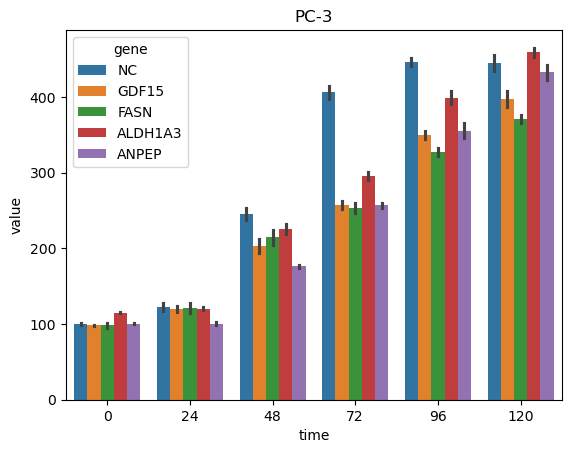

In [67]:
plot_proliferation(df)

In [68]:
!pwd

/storage1/fs1/dinglab/Active/Projects/estorrs/3d-analysis/notebooks


## migration

In [159]:
df = pd.read_csv(StringIO("""disease	cell_line	gene	replicate	0h area	24h area	Migraton percentage	trial
breast	ETCC-006	NC	1	1816043	1639743	0.275280444	MGP_PLAT
breast	ETCC-006	NC	2	1692650	1537600	0.239660666	MGP_PLAT
breast	ETCC-006	NC	3	1562059	1309875	0.247744779	MGP_PLAT
breast	ETCC-006	MGP	1	1779558	837238	0.47137746	MGP_PLAT
breast	ETCC-006	MGP	2	1729074	953591	0.560835422	MGP_PLAT
breast	ETCC-006	MGP	3	1800831	1071667	0.564504777	MGP_PLAT
breast	ETCC-006	PLAT	1	1629861	1175631	0.424606946	MGP_PLAT
breast	ETCC-006	PLAT	2	1531536	1022086	0.378152918	MGP_PLAT
breast	ETCC-006	PLAT	3	1586303	1055375	0.365464472	MGP_PLAT
breast	ETCC-010	NC	1	1816043	1639743	0.097079199	MGP_PLAT
breast	ETCC-010	NC	2	1692650	1537600	0.091601926	MGP_PLAT
breast	ETCC-010	NC	3	1562059	1309875	0.161443326	MGP_PLAT
breast	ETCC-010	MGP	1	1779558	837238	0.529524747	MGP_PLAT
breast	ETCC-010	MGP	2	1729074	953591	0.448496131	MGP_PLAT
breast	ETCC-010	MGP	3	1800831	1071667	0.40490418	MGP_PLAT
breast	ETCC-010	PLAT	1	1629861	1175631	0.278692477	MGP_PLAT
breast	ETCC-010	PLAT	2	1531536	1022086	0.332639912	MGP_PLAT
breast	ETCC-010	PLAT	3	1586303	1055375	0.3346952	MGP_PLAT"""), sep='\t')
df

,disease,cell_line,gene,replicate,0h area,24h area,Migraton percentage,trial
0,breast,ETCC-006,NC,1,1816043,1639743,0.275280,MGP_PLAT
1,breast,ETCC-006,NC,2,1692650,1537600,0.239661,MGP_PLAT
2,breast,ETCC-006,NC,3,1562059,1309875,0.247745,MGP_PLAT
3,breast,ETCC-006,MGP,1,1779558,837238,0.471377,MGP_PLAT
4,breast,ETCC-006,MGP,2,1729074,953591,0.560835,MGP_PLAT
5,breast,ETCC-006,MGP,3,1800831,1071667,0.564505,MGP_PLAT
6,breast,ETCC-006,PLAT,1,1629861,1175631,0.424607,MGP_PLAT
7,breast,ETCC-006,PLAT,2,1531536,1022086,0.378153,MGP_PLAT
8,breast,ETCC-006,PLAT,3,1586303,1055375,0.365464,MGP_PLAT
9,breast,ETCC-010,NC,1,1816043,1639743,0.097079,MGP_PLAT


In [160]:
def add_relative_migration(df):
    ## calculate migration
    trial_to_value = df[df['gene']=='NC'][['cell_line', 'trial', 'Migraton percentage']].groupby(['cell_line', 'trial']).mean()

    data = []
    for i, row in df.iterrows():
        ctrl = trial_to_value.loc[(row['cell_line'], row['trial'])].item()
        val = (row['Migraton percentage'] / ctrl) * 100
        data.append(val)

    df['relative_migration'] = data
    return df


In [161]:
def plot_migration(df):
    for cl in set(df['cell_line']):
        source = df[df['cell_line'] == cl].copy()

        sns.barplot(source, x='gene', y='relative_migration', errorbar='se')
        plt.title(cl)
        plt.savefig(output_dir / f'functional_migration_{cl}.svg')
        plt.show()

In [162]:
df = add_relative_migration(df)
df

,disease,cell_line,gene,replicate,0h area,24h area,Migraton percentage,trial,relative_migration
0,breast,ETCC-006,NC,1,1816043,1639743,0.275280,MGP_PLAT,108.280662
1,breast,ETCC-006,NC,2,1692650,1537600,0.239661,MGP_PLAT,94.269739
2,breast,ETCC-006,NC,3,1562059,1309875,0.247745,MGP_PLAT,97.449599
3,breast,ETCC-006,MGP,1,1779558,837238,0.471377,MGP_PLAT,185.414782
4,breast,ETCC-006,MGP,2,1729074,953591,0.560835,MGP_PLAT,220.602779
5,breast,ETCC-006,MGP,3,1800831,1071667,0.564505,MGP_PLAT,222.046108
6,breast,ETCC-006,PLAT,1,1629861,1175631,0.424607,MGP_PLAT,167.017753
7,breast,ETCC-006,PLAT,2,1531536,1022086,0.378153,MGP_PLAT,148.745214
8,breast,ETCC-006,PLAT,3,1586303,1055375,0.365464,MGP_PLAT,143.754255
9,breast,ETCC-010,NC,1,1816043,1639743,0.097079,MGP_PLAT,83.181165


In [171]:
def get_migration_stats(df):
    for trial in set(df['trial']):
        for cl in set(df['cell_line']):
            f = df[(
                (df['trial'] == trial) &\
                (df['cell_line'] == cl)
            )]
            for gene in set(f['gene']):
                xs = f[f['gene'] == gene]['Migraton percentage'].values
                ys = f[f['gene'] == 'NC']['Migraton percentage'].values
                _, pval, _ = ttest_ind(xs, ys)
                print(cl, trial, gene, pval)


In [172]:
get_migration_stats(df)

ETCC-006 MGP_PLAT PLAT 0.00297592958879747
ETCC-006 MGP_PLAT NC 1.0
ETCC-006 MGP_PLAT MGP 0.001001612068320324
ETCC-010 MGP_PLAT PLAT 0.002367213114060231
ETCC-010 MGP_PLAT NC 1.0
ETCC-010 MGP_PLAT MGP 0.0013023059280388184


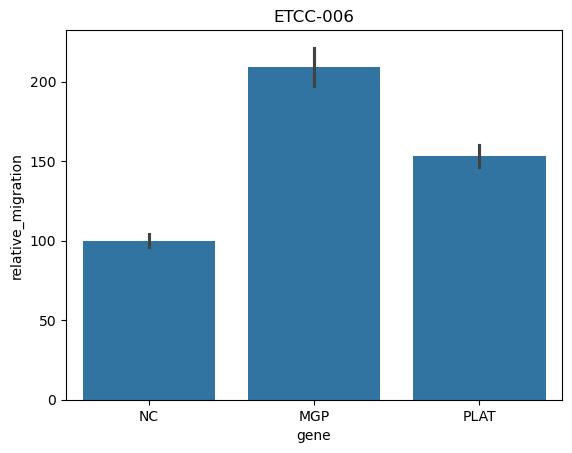

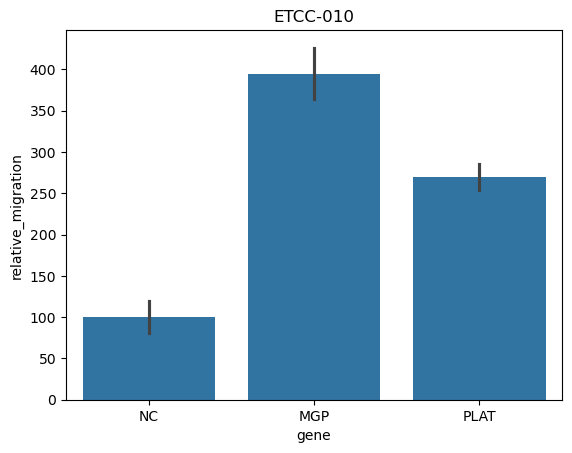

In [147]:
plot_migration(df)

In [173]:
df = pd.read_csv(StringIO("""disease	cell_line	trial	gene	replicate	0h area	72h area	Migraton percentage
breast	PC-3	GDF15	NC	1	711395	146018	0.794744129
breast	PC-3	GDF15	NC	2	730692	113593	0.844540518
breast	PC-3	GDF15	NC	3	670757	151463	0.774190951
breast	PC-3	GDF15	GDF15	1	774512	303742	0.607827897
breast	PC-3	GDF15	GDF15	2	650460	366565	0.436452664
breast	PC-3	GDF15	GDF15	3	635952	415247	0.347046632
breast	PC-3	FASN	NC	1	828934	286744	0.654081025
breast	PC-3	FASN	NC	2	913235	227853	0.75049905
breast	PC-3	FASN	NC	3	841028	225576	0.731785386
breast	PC-3	FASN	FASN	1	735635	400952	0.454957961
breast	PC-3	FASN	FASN	2	799808	468782	0.413881832
breast	PC-3	FASN	FASN	3	881681	390613	0.556967883
breast	PC-3	ALDH1A3	NC	1	880212	379092	0.569317392
breast	PC-3	ALDH1A3	NC	2	793476	381374	0.519362904
breast	PC-3	ALDH1A3	NC	3	821582	371459	0.547873493
breast	PC-3	ALDH1A3	ALDH1A3	1	1286778	791089	0.385217186
breast	PC-3	ALDH1A3	ALDH1A3	2	1212543	835929	0.310598469
breast	PC-3	ALDH1A3	ALDH1A3	3	1160387	802299	0.308593599
breast	PC-3	ANPEP	NC	1	880212	379092	0.569317392
breast	PC-3	ANPEP	NC	2	793476	381374	0.519362904
breast	PC-3	ANPEP	NC	3	821582	371459	0.547873493
breast	PC-3	ANPEP	ANPEP	1	778714	416120	0.465631798
breast	PC-3	ANPEP	ANPEP	2	738175	442660	0.4003319
breast	PC-3	ANPEP	ANPEP	3	771105	470743	0.389521531"""), sep='\t')
df

,disease,cell_line,trial,gene,replicate,0h area,72h area,Migraton percentage
0,breast,PC-3,GDF15,NC,1,711395,146018,0.794744
1,breast,PC-3,GDF15,NC,2,730692,113593,0.844541
2,breast,PC-3,GDF15,NC,3,670757,151463,0.774191
3,breast,PC-3,GDF15,GDF15,1,774512,303742,0.607828
4,breast,PC-3,GDF15,GDF15,2,650460,366565,0.436453
5,breast,PC-3,GDF15,GDF15,3,635952,415247,0.347047
6,breast,PC-3,FASN,NC,1,828934,286744,0.654081
7,breast,PC-3,FASN,NC,2,913235,227853,0.750499
8,breast,PC-3,FASN,NC,3,841028,225576,0.731785
9,breast,PC-3,FASN,FASN,1,735635,400952,0.454958


In [174]:
df = add_relative_migration(df)
df

,disease,cell_line,trial,gene,replicate,0h area,72h area,Migraton percentage,relative_migration
0,breast,PC-3,GDF15,NC,1,711395,146018,0.794744,98.788336
1,breast,PC-3,GDF15,NC,2,730692,113593,0.844541,104.978130
2,breast,PC-3,GDF15,NC,3,670757,151463,0.774191,96.233534
3,breast,PC-3,GDF15,GDF15,1,774512,303742,0.607828,75.554263
4,breast,PC-3,GDF15,GDF15,2,650460,366565,0.436453,54.251967
5,breast,PC-3,GDF15,GDF15,3,635952,415247,0.347047,43.138613
6,breast,PC-3,FASN,NC,1,828934,286744,0.654081,91.849597
7,breast,PC-3,FASN,NC,2,913235,227853,0.750499,105.389138
8,breast,PC-3,FASN,NC,3,841028,225576,0.731785,102.761264
9,breast,PC-3,FASN,FASN,1,735635,400952,0.454958,63.887659


In [175]:
get_migration_stats(df)

PC-3 GDF15 GDF15 0.012685590411059947
PC-3 GDF15 NC 1.0
PC-3 ANPEP ANPEP 0.01030653706494722
PC-3 ANPEP NC 1.0
PC-3 ALDH1A3 ALDH1A3 0.001922948644666245
PC-3 ALDH1A3 NC 1.0
PC-3 FASN NC 1.0
PC-3 FASN FASN 0.010224648004003932


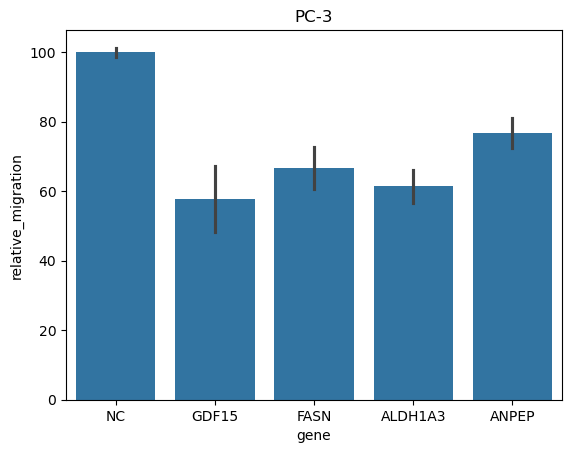

In [154]:
plot_migration(df)

In [111]:
df = pd.read_csv(StringIO("""case	assay	section	Tumor_Type	site
SP017Z1	Xenium	SP017Z1-U17	Primary	Prostate
SP017Z1	Xenium	SP017Z1-U2	Primary	Prostate
SP017Z1	Xenium	SP017Z1-U24	Primary	Prostate
SP017Z1	Xenium	SP017Z1-U9	Primary	Prostate
SP003Z1	Xenium	SP003Z1-Fp1A15Us1_1	Primary	Prostate
SP004Z1	Xenium	SP004Z1-Fp1B17Us2_1	Primary	Prostate
SP005Z1	Xenium	SP005Z1-Fp1A25Us1_1	Primary	Prostate
SP006Z1	Xenium	SP006Z1-Fp1C8Us1_1	Primary	Prostate
SP008Z1	Xenium	SP008Z1-Fp1F15U1	Primary	Prostate
SP009Z1	Xenium	SP009Z1-Fp1B14U1	Primary	Prostate
SP012Z1	Xenium	SP012Z1-Fp1-A2U3	Primary	Prostate
SP015Z1	Xenium	SP015Z1-Fp1A1U3	Primary	Prostate
SP006Z1	Xenium	SP006Z1-C8-U1	Primary	Prostate
SP006Z1	Xenium	SP006Z1-C8-U12	Primary	Prostate
SP006Z1	Xenium	SP006Z1-C8-U18	Primary	Prostate
SP006Z1	Xenium	SP006Z1-C8-U20	Primary	Prostate
SP006Z1	Xenium	SP006Z1-C8-U5	Primary	Prostate
SP006Z1	Xenium	SP006Z1-C8-U7	Primary	Prostate
HT814Z1	Xenium	HT814Z1-S1H1Fp1Us1_3	Primary	Prostate
HT817Z1	Xenium	HT817Z1-S1H1Fp1Us1_2	Primary	Prostate
SP007Z1	Xenium	SP007Z1-Fp1A10Us2_1	Primary	Prostate
HT832Z1	Xenium	HT832Z1-S1H1Fp1U1	Primary	Prostate
SP016Z1	Xenium	SP016Z1-Fp1B28U1	Primary	Prostate
HT849Z1	Xenium	HT849Z1-S1H2Fp1U1	Primary	Prostate
HT852Z1	Xenium	HT852Z1-S1H1Fp1U1	Primary	Prostate
SP011Z1	Xenium	SP011Z1-Fp1-A15U1	Primary	Prostate
SP014Z1	Xenium	SP014Z1-Fp1A29U1	Primary	Prostate
HT891Z1	Xenium	HT891Z1-U1	Primary	Prostate
HT891Z1	Xenium	HT891Z1-U21	Primary	Prostate
HT891Z1	Xenium	HT891Z1-U32	Primary	Prostate
HT891Z1	Xenium	HT891Z1-U44	Primary	Prostate
HT891Z1	Xenium	HT891Z1-U59	Primary	Prostate
HT891Z1	Xenium	HT891Z1-U69	Primary	Prostate
HT891Z1	Xenium	HT891Z1-U104	Primary	Prostate
HT891Z1	Xenium	HT891Z1-U81	Primary	Prostate
HT891Z1	Xenium	HT891Z1-U94	Primary	Prostate
HT913Z1	Xenium	HT913Z1-U101	Primary	Prostate
HT913Z1	Xenium	HT913Z1-U33	Primary	Prostate
HT913Z1	Xenium	HT913Z1-U34	Primary	Prostate
HT913Z1	Xenium	HT913Z1-U35	Primary	Prostate
HT913Z1	Xenium	HT913Z1-U61	Primary	Prostate
HT913Z1	Xenium	HT913Z1-U81	Primary	Prostate
HT913Z1	Xenium	HT913Z1-U1	Primary	Prostate
HT913Z1	Xenium	HT913Z1-U11	Primary	Prostate
HT913Z1	Xenium	HT913Z1-U21	Primary	Prostate
HT913Z1	Xenium	HT913Z1-S1H1Fp1U1	Primary	Prostate
HT913Z1	Xenium	HT913Z1-S1H1Fp1U11	Primary	Prostate
HT913Z1	Xenium	HT913Z1-S1H1Fp1U8	Primary	Prostate
SP048Z1	Xenium	SP048Z1-Fp1C27U1	Primary	Prostate
SP016Z1	Xenium	SP016Z1-Fp1B28U2	Primary	Prostate
HT832Z1	Xenium	HT832Z1-S1H1Fp1U2	Primary	Prostate
HT1011Z1	Xenium	HT1011Z1-S1H3Fp1U1	Primary	Prostate
HT206B1	Xenium	HT206B1-U9	Primary	Breast
HT206B1	Xenium	HT206B1-U17	Primary	Breast
HT206B1	Xenium	HT206B1-U1	Primary	Breast
HT206B1	Xenium	HT206B1-U24	Primary	Breast
HT206B1	Xenium	HT206B1-U8	Primary	Breast
HT206B1	Xenium	HT206B1-U16	Primary	Breast
HT591B1	Xenium	HT591B1-S1H1Fp1Us1_1	Primary	Breast
HT704B1	Xenium	HT704B1-U1	Primary	Breast
HT704B1	Xenium	HT704B1-U17	Primary	Breast
HT704B1	Xenium	HT704B1-U26	Primary	Breast
HT704B1	Xenium	HT704B1-U33	Primary	Breast
HT704B1	Xenium	HT704B1-U41	Primary	Breast
HT704B1	Xenium	HT704B1-U50	Primary	Breast
1581620AU1	Xenium	1581620AU1	Primary	Breast
1654977AU1	Xenium	1654977AU1	Primary	Breast
HT727B1	Xenium	HT727B1-S1H4Fp1U1	Primary	Breast
1661918aU1	Xenium	1661918aU1	Primary	Breast
1607059U1	Xenium	1607059U1	Primary	Breast
HT944B1	Xenium	HT944B1-S2H2bFpU1	Primary	Breast
SP048Z1	Xenium	SP048Z1-Fp1C27U2	Primary	Prostate
SP051Z1	Xenium	SP051Z1-Fp1F1U2	Primary	Prostate
SP050Z1	Xenium	SP050Z1-Fp1A1U2	Primary	Prostate
SP012Z1	CosMx	SP012Z1-Fp1A2-Ux	Primary	Prostate
SP012Z1	CosMx	SP012Z1-Fp1A15-Ux	Primary	Prostate
SP005Z1	CosMx	SP005Z1-Fp1A25-Ux	Primary	Prostate
HT913Z1	CosMx	HT913Z1-S1H1Fp1	Primary	Prostate
HT891Z1	CosMx	HT891Z1-S2H1Fp1	Primary	Prostate
HT891Z1	CosMx	HT891Z1-S2H4Fp1	Primary	Prostate
HT891Z1	CosMx	HT891Z1-U57	Primary	Prostate
HT891Z1	CosMx	HT891Z1-U60	Primary	Prostate
HT938Z1	CosMx	HT938Z1-S1H1FP1U1	Primary	Prostate
HT997Z1	CosMx	HT997Z1-S1H1FP1U1	Primary	Prostate
HT935Z1	CosMx	HT935Z1-S1H1FP1U2	Primary	Prostate
HT206B1	CosMx	HT206B1-U23	Primary	Breast
HT704B1	CosMx	HT704B1-U14	Primary	Breast
HT704B1	CosMx	HT704B1-U22	Primary	Breast
HT704B1	CosMx	HT704B1-U47	Primary	Breast
HT704B1	CosMx	HT704B1-U56	Primary	Breast
HT891Z1	VisiumHD	HT891Z1-U2	Primary	Prostate
HT891Z1	VisiumHD	HT891Z1-U33	Primary	Prostate
HT935Z1	VisiumHD	HT935Z1-S1H1Fp1U1	Primary	Prostate
HT704B1	VisiumHD	HT704B1-U2	Primary	Breast
HT704B1	VisiumHD	HT704B1-U51	Primary	Breast
HT935Z1	VisiumHD	HT935Z1-S1H1Fp1U2	Primary	Prostate
HT727B1	VisiumHD	HT727B1-S1H4Fp1U1	Primary	Breast
HT206B1	Visium	HT206B1-S1Fc1U1Z1B1	Primary	Breast
HT206B1	Visium	HT206B1-S1Fc1U2Z1B1	Primary	Breast
HT206B1	Visium	HT206B1-S1Fc1U3Z1B1	Primary	Breast
HT206B1	Visium	HT206B1-S1Fc1U4Z1B1	Primary	Breast
HT206B1	Visium	HT206B1-S1Fc1U5Z1B1	Primary	Breast
HT297B1	Visium	HT297B1-S1H1Fc2U1Z1Bs1	Primary	Breast
HT308B1	Visium	HT308B1-S1H1Fc2U1Z1Bs1	Primary	Breast
HT308B1	Visium	HT308B1-S1H5Fc2U1Z1Bs1	Primary	Breast
HT308B1	Visium	HT308B1-S1H4Fc2U1Z1Bs1	Primary	Breast
HT323B1	Visium	HT323B1-S1H1Fc2U1Z1Bs1	Primary	Breast
HT339B1	Visium	HT339B1-S1H3Fc2U1Z1Bs1	Primary	Breast
HT339B1	Visium	HT339B1-S1H3Fc2U2Bs2	Primary	Breast
HT397B1	Visium	HT397B1-S1H3Fs1U1Bp1	Primary	Breast
HT397B1	Visium	HT397B1-S1H2Fs4U1Bp1	Primary	Breast
HT397B1	Visium	HT397B1-U1	Primary	Breast
HT397B1	Visium	HT397B1-U21	Primary	Breast
HT397B1	Visium	HT397B1-U41	Primary	Breast
HT397B1	Visium	HT397B1-U61	Primary	Breast
HT425B1	Visium	HT425B1-S1H2Fs1U2Bp1	Primary	Breast
HT480B1	Visium	HT480B1-S1H1Fs1U1Bp1	Primary	Breast
HT480B1	Visium	HT480B1-S1H3Fs1U1Bp1	Primary	Breast
HT480B1	Visium	HT480B1-S1H1Fs1U2Bp1	Primary	Breast
HT486B1	Visium	HT486B1-S1H1Fs1U1Bp1	Primary	Breast
HT486B1	Visium	HT486B1-S1H1Fs1U2Bp1	Primary	Breast
SP017Z1	Visium	SP017Z1-U1	Primary	Prostate
SP017Z1	Visium	SP017Z1-U16	Primary	Prostate
SP060Z1	Visium	SP060Z1-Fp1U1Bp1	Primary	Prostate
SP008Z1	Visium	SP008Z1-Fp1F15U1Bp1	Primary	Prostate
HT206B1	xenium	HT206B1-U1		breast
HT206B1	he	HT206B1-U4		breast
HT206B1	codex	HT206B1-U2		breast
HT206B1	codex	HT206B1-U5		breast
HT206B1	xenium	HT206B1-U8		breast
HT206B1	xenium	HT206B1-U9		breast
HT206B1	codex	HT206B1-U10		breast
HT206B1	he	HT206B1-U12		breast
HT206B1	codex	HT206B1-U13		breast
HT206B1	cosmx	HT206B1-U15		breast
HT206B1	xenium	HT206B1-U16		breast
HT206B1	xenium	HT206B1-U17		breast
HT206B1	codex	HT206B1-U18		breast
HT206B1	he	HT206B1-U20		breast
HT206B1	codex	HT206B1-U21		breast
HT206B1	xenium	HT206B1-U24		breast
HT339B2	visium	HT339B2-H1-U1		breast
HT339B2	codex	HT339B2-H1-U2		breast
HT397B1	visium	HT397B1-U1		breast
HT397B1	codex	HT397B1-U2		breast
HT397B1	he	HT397B1-U4		breast
HT397B1	he	HT397B1-U8		breast
HT397B1	he	HT397B1-U11		breast
HT397B1	codex	HT397B1-U12		breast
HT397B1	he	HT397B1-U16		breast
HT397B1	visium	HT397B1-U21		breast
HT397B1	codex	HT397B1-U22		breast
HT397B1	he	HT397B1-U20		breast
HT397B1	he	HT397B1-U28		breast
HT397B1	codex	HT397B1-U31		breast
HT565B1	visium	HT565B1-H2-U1		breast
HT565B1	codex	HT565B1-H2-U2		breast
HT704B1	xenium	HT704B1-U1		breast
HT704B1	visiumhd	HT704B1-U2		breast
HT704B1	codex	HT704B1-U11		breast
HT704B1	he	HT704B1-U12		breast
HT704B1	cosmx	HT704B1-U14		breast
HT704B1	he	HT704B1-U15		breast
HT704B1	xenium	HT704B1-U17		breast
HT704B1	codex	HT704B1-U19		breast
HT704B1	he	HT704B1-U20		breast
HT704B1	cosmx	HT704B1-U22		breast
HT704B1	he	HT704B1-U23		breast
HT704B1	xenium	HT704B1-U26		breast
HT704B1	codex	HT704B1-U27		breast
HT704B1	he	HT704B1-U28		breast
HT704B1	he	HT704B1-U31		breast
HT704B1	xenium	HT704B1-U33		breast
HT704B1	codex	HT704B1-U35		breast
HT704B1	he	HT704B1-U36		breast
HT704B1	he	HT704B1-U39		breast
HT704B1	xenium	HT704B1-U41		breast
HT704B1	codex	HT704B1-U43		breast
HT704B1	he	HT704B1-U44		breast
HT704B1	cosmx	HT704B1-U47		breast
HT704B1	he	HT704B1-U48		breast
HT704B1	xenium	HT704B1-U50		breast
HT704B1	visiumhd	HT704B1-U51		breast
HT704B1	codex	HT704B1-U53		breast
HT704B1	he	HT704B1-U54		breast
HT704B1	cosmx	HT704B1-U56		breast
HT704B1	he	HT704B1-U57		breast
HT704B1	codex	HT704B1-U60		breast
HT704B1	he	HT704B1-U61		breast
HT704B1	he	HT704B1-U65		breast
HT704B1	codex	HT704B1-U68		breast
HT704B1	he	HT704B1-U69		breast
HT704B1	he	HT704B1-U73		breast
HT704B1	codex	HT704B1-U76		breast
HT704B1	he	HT704B1-U81		breast
HT704B1	codex	HT704B1-U82		breast
HT704B1	he	HT704B1-U84		breast
HT704B1	codex	HT704B1-U85		breast
HT704B1	codex	HT704B1-U91		breast
HT704B1	he	HT704B1-U90		breast
HT704B1	he	HT704B1-U93		breast
HT891Z1	xenium	HT891Z1-U1		prostate
HT891Z1	he	HT891Z1-U4		prostate
HT891Z1	visiumhd	HT891Z1-U2		prostate
HT891Z1	he	HT891Z1-U5		prostate
HT891Z1	he	HT891Z1-U6		prostate
HT891Z1	he	HT891Z1-U7		prostate
HT891Z1	codex	HT891Z1-U14		prostate
HT891Z1	xenium	HT891Z1-U21		prostate
HT891Z1	he	HT891Z1-U28		prostate
HT891Z1	he	HT891Z1-U29		prostate
HT891Z1	he	HT891Z1-U30		prostate
HT891Z1	xenium	HT891Z1-U31		prostate
HT891Z1	codex	HT891Z1-U32		prostate
HT891Z1	visiumhd	HT891Z1-U33		prostate
HT891Z1	he	HT891Z1-U35		prostate
HT891Z1	codex	HT891Z1-U40		prostate
HT891Z1	codex	HT891Z1-U41		prostate
HT891Z1	codex	HT891Z1-U43		prostate
HT891Z1	xenium	HT891Z1-U44		prostate
HT891Z1	codex	HT891Z1-U45		prostate
HT891Z1	codex	HT891Z1-U46		prostate
HT891Z1	he	HT891Z1-U47		prostate
HT891Z1	he	HT891Z1-U48		prostate
HT891Z1	he	HT891Z1-U49		prostate
HT891Z1	he	HT891Z1-U50		prostate
HT891Z1	cosmx	HT891Z1-U57		prostate
HT891Z1	codex	HT891Z1-U58		prostate
HT891Z1	xenium	HT891Z1-U59		prostate
HT891Z1	cosmx	HT891Z1-U60		prostate
HT891Z1	he	HT891Z1-U66		prostate
HT891Z1	he	HT891Z1-U68		prostate
HT891Z1	xenium	HT891Z1-U69		prostate
HT891Z1	he	HT891Z1-U70		prostate
HT891Z1	codex	HT891Z1-U79		prostate
HT891Z1	xenium	HT891Z1-U81		prostate
HT891Z1	he	HT891Z1-U84		prostate
HT891Z1	he	HT891Z1-U89		prostate
HT891Z1	he	HT891Z1-U90		prostate
HT891Z1	codex	HT891Z1-U93		prostate
HT891Z1	xenium	HT891Z1-U94		prostate
HT891Z1	he	HT891Z1-U101		prostate
HT891Z1	he	HT891Z1-U102		prostate
HT891Z1	codex	HT891Z1-U103		prostate
HT891Z1	xenium	HT891Z1-U104		prostate
HT891Z1	he	HT891Z1-U106		prostate
HT891Z1	he	HT891Z1-U107		prostate
HT891Z1	codex	HT891Z1-U108		prostate
HT891Z1	codex	HT891Z1-U109		prostate
HT891Z1	codex	HT891Z1-U110		prostate
HT891Z1	codex	HT891Z1-U111		prostate
HT891Z1	codex	HT891Z1-U113		prostate
HT891Z1	he	HT891Z1-U114		prostate
HT891Z1	he	HT891Z1-U115		prostate
HT891Z1	he	HT891Z1-U116		prostate
HT913Z1	xenium	HT913Z1-U1		prostate
HT913Z1	codex	HT913Z1-U2		prostate
HT913Z1	he	HT913Z1-U3		prostate
HT913Z1	he	HT913Z1-U5		prostate
HT913Z1	he	HT913Z1-U7		prostate
HT913Z1	he	HT913Z1-U9		prostate
HT913Z1	he	HT913Z1-U10		prostate
HT913Z1	xenium	HT913Z1-U11		prostate
HT913Z1	codex	HT913Z1-U12		prostate
HT913Z1	he	HT913Z1-U13		prostate
HT913Z1	he	HT913Z1-U15		prostate
HT913Z1	he	HT913Z1-U17		prostate
HT913Z1	he	HT913Z1-U19		prostate
HT913Z1	xenium	HT913Z1-U21		prostate
HT913Z1	codex	HT913Z1-U22		prostate
HT913Z1	he	HT913Z1-U24		prostate
HT913Z1	he	HT913Z1-U26		prostate
HT913Z1	he	HT913Z1-U28		prostate
HT913Z1	he	HT913Z1-U30		prostate
HT913Z1	xenium	HT913Z1-U33		prostate
HT913Z1	xenium	HT913Z1-U34		prostate
HT913Z1	xenium	HT913Z1-U35		prostate
HT913Z1	he	HT913Z1-U36		prostate
HT913Z1	he	HT913Z1-U38		prostate
HT913Z1	he	HT913Z1-U40		prostate
HT913Z1	codex	HT913Z1-U41		prostate
HT913Z1	he	HT913Z1-U42		prostate
HT913Z1	he	HT913Z1-U44		prostate
HT913Z1	he	HT913Z1-U46		prostate
HT913Z1	he	HT913Z1-U48		prostate
HT913Z1	he	HT913Z1-U50		prostate
HT913Z1	codex	HT913Z1-U51		prostate
HT913Z1	codex	HT913Z1-U52		prostate
HT913Z1	codex	HT913Z1-U53		prostate
HT913Z1	codex	HT913Z1-U54		prostate
HT913Z1	he	HT913Z1-U55		prostate
HT913Z1	he	HT913Z1-U57		prostate
HT913Z1	xenium	HT913Z1-U61		prostate
HT913Z1	codex	HT913Z1-U62		prostate
HT913Z1	he	HT913Z1-U63		prostate
HT913Z1	he	HT913Z1-U65		prostate
HT913Z1	he	HT913Z1-U67		prostate
HT913Z1	he	HT913Z1-U69		prostate
HT913Z1	codex	HT913Z1-U71		prostate
HT913Z1	he	HT913Z1-U72		prostate
HT913Z1	he	HT913Z1-U74		prostate
HT913Z1	he	HT913Z1-U76		prostate
HT913Z1	he	HT913Z1-U78		prostate
HT913Z1	he	HT913Z1-U80		prostate
HT913Z1	xenium	HT913Z1-U81		prostate
HT913Z1	codex	HT913Z1-U82		prostate
HT913Z1	he	HT913Z1-U83		prostate
HT913Z1	he	HT913Z1-U85		prostate
HT913Z1	he	HT913Z1-U87		prostate
HT913Z1	he	HT913Z1-U89		prostate
HT913Z1	codex	HT913Z1-U91		prostate
HT913Z1	he	HT913Z1-U92		prostate
HT913Z1	he	HT913Z1-U94		prostate
HT913Z1	he	HT913Z1-U96		prostate
HT913Z1	he	HT913Z1-U99		prostate
HT913Z1	xenium	HT913Z1-U101		prostate
HT913Z1	codex	HT913Z1-U102		prostate
HT913Z1	he	HT913Z1-U103		prostate
HT913Z1	he	HT913Z1-U106		prostate
HT913Z1	he	HT913Z1-U108		prostate
HT913Z1	he	HT913Z1-U110		prostate
HT913Z1	codex	HT913Z1-U111		prostate
HT913Z1	he	HT913Z1-U112		prostate
HT913Z1	he	HT913Z1-U115		prostate
HT913Z1	he	HT913Z1-U117		prostate
HT913Z1	he	HT913Z1-U119		prostate
HT913Z1	he	HT913Z1-U120		prostate
HT913Z1	codex	HT913Z1-U121		prostate
HT913Z1	he	HT913Z1-U122		prostate
HT913Z1	he	HT913Z1-U124		prostate
HT913Z1	codex	HT913Z1-U125		prostate
SP006Z1	xenium	SP006Z1-C8-U1		prostate
SP006Z1	he	SP006Z1-C8-U3		prostate
SP006Z1	xenium	SP006Z1-C8-U5		prostate
SP006Z1	xenium	SP006Z1-C8-U7		prostate
SP006Z1	codex	SP006Z1-C8-U8		prostate
SP006Z1	he	SP006Z1-C8-U9		prostate
SP006Z1	xenium	SP006Z1-C8-U12		prostate
SP006Z1	codex	SP006Z1-C8-U14		prostate
SP006Z1	xenium	SP006Z1-C8-U18		prostate
SP006Z1	codex	SP006Z1-C8-U19		prostate
SP006Z1	xenium	SP006Z1-C8-U20		prostate
SP006Z1	codex	SP006Z1-C8-U21		prostate
SP006Z1	codex	SP006Z1-C8-U23		prostate
SP006Z1	codex	SP006Z1-C8-U24		prostate
SP017Z1	visium	SP017Z1-U1		prostate
SP017Z1	xenium	SP017Z1-U2		prostate
SP017Z1	codex	SP017Z1-U3		prostate
SP017Z1	he	SP017Z1-U5		prostate
SP017Z1	xenium	SP017Z1-U9		prostate
SP017Z1	codex	SP017Z1-U10		prostate
SP017Z1	he	SP017Z1-U12		prostate
SP017Z1	visium	SP017Z1-U16		prostate
SP017Z1	xenium	SP017Z1-U17		prostate
SP017Z1	codex	SP017Z1-U18		prostate
SP017Z1	he	SP017Z1-U20		prostate
SP017Z1	xenium	SP017Z1-U24		prostate
SP017Z1	codex	SP017Z1-U25		prostate"""), sep='\t')
df

,case,assay,section,Tumor_Type,site
0,SP017Z1,Xenium,SP017Z1-U17,Primary,Prostate
1,SP017Z1,Xenium,SP017Z1-U2,Primary,Prostate
2,SP017Z1,Xenium,SP017Z1-U24,Primary,Prostate
3,SP017Z1,Xenium,SP017Z1-U9,Primary,Prostate
4,SP003Z1,Xenium,SP003Z1-Fp1A15Us1_1,Primary,Prostate
...,...,...,...,...,...
353,SP017Z1,xenium,SP017Z1-U17,NaN,prostate
354,SP017Z1,codex,SP017Z1-U18,NaN,prostate
355,SP017Z1,he,SP017Z1-U20,NaN,prostate
356,SP017Z1,xenium,SP017Z1-U24,NaN,prostate


In [113]:
df = df[['case', 'assay', 'section', 'site']]
df['assay'] = [x.lower() for x in df['assay']]
df['site'] = [x.lower() for x in df['site']]
df['section'] = [x.lower() for x in df['section']]
df = df.drop_duplicates()
df

,case,assay,section,site
0,SP017Z1,xenium,sp017z1-u17,prostate
1,SP017Z1,xenium,sp017z1-u2,prostate
2,SP017Z1,xenium,sp017z1-u24,prostate
3,SP017Z1,xenium,sp017z1-u9,prostate
4,SP003Z1,xenium,sp003z1-fp1a15us1_1,prostate
...,...,...,...,...
350,SP017Z1,codex,sp017z1-u10,prostate
351,SP017Z1,he,sp017z1-u12,prostate
354,SP017Z1,codex,sp017z1-u18,prostate
355,SP017Z1,he,sp017z1-u20,prostate


In [114]:
df[['site', 'assay']].groupby('site').count()

,assay
site,
breast,107
prostate,198


In [115]:
df[['section', 'assay']].groupby('assay').count()

,section
assay,
codex,66
cosmx,17
he,110
visium,30
visiumhd,7
xenium,75


In [119]:
df[['case', 'assay']].drop_duplicates().groupby('assay').count()

,case
assay,
codex,9
cosmx,9
he,7
visium,14
visiumhd,4
xenium,33


In [124]:
df[['case', 'site']].drop_duplicates().groupby('site').count()

,case
site,
breast,19
prostate,28


In [122]:
dropped = df[['case', 'assay', 'site']].drop_duplicates()
dropped

,case,assay,site
0,SP017Z1,xenium,prostate
4,SP003Z1,xenium,prostate
5,SP004Z1,xenium,prostate
6,SP005Z1,xenium,prostate
7,SP006Z1,xenium,prostate
...,...,...,...
257,HT913Z1,he,prostate
332,SP006Z1,he,prostate
335,SP006Z1,codex,prostate
347,SP017Z1,codex,prostate


In [125]:
dropped[dropped['site']=='prostate']

,case,assay,site
0,SP017Z1,xenium,prostate
4,SP003Z1,xenium,prostate
5,SP004Z1,xenium,prostate
6,SP005Z1,xenium,prostate
7,SP006Z1,xenium,prostate
8,SP008Z1,xenium,prostate
9,SP009Z1,xenium,prostate
10,SP012Z1,xenium,prostate
11,SP015Z1,xenium,prostate
18,HT814Z1,xenium,prostate


In [118]:
df[df['assay']=='xenium']

,case,assay,section,site
0,SP017Z1,xenium,sp017z1-u17,prostate
1,SP017Z1,xenium,sp017z1-u2,prostate
2,SP017Z1,xenium,sp017z1-u24,prostate
3,SP017Z1,xenium,sp017z1-u9,prostate
4,SP003Z1,xenium,sp003z1-fp1a15us1_1,prostate
...,...,...,...,...
70,HT944B1,xenium,ht944b1-s2h2bfpu1,breast
71,SP048Z1,xenium,sp048z1-fp1c27u2,prostate
72,SP051Z1,xenium,sp051z1-fp1f1u2,prostate
73,SP050Z1,xenium,sp050z1-fp1a1u2,prostate


In [109]:
df[['Site', 'Assay_Type']].groupby('Site').count()

,Assay_Type
Site,
Breast,51
Prostate,74


In [100]:
df[['Section_ID', 'Assay_Type']].groupby('Assay_Type').count()

,Section_ID
Assay_Type,
CosMx,16
Visium,28
VisiumHD,7
Xenium,74


In [106]:
df[['Case', 'Assay_Type']].drop_duplicates().groupby('Assay_Type').count()

,Case
Assay_Type,
CosMx,9
Visium,12
VisiumHD,4
Xenium,33


In [110]:
df[['Case', 'Assay_Type', 'Site']].drop_duplicates().groupby('Site').count()

,Case,Assay_Type
Site,,
Breast,22,22
Prostate,36,36


In [126]:
df = pd.read_csv(StringIO("""711395	146018
730692	113593
670757	151463
774512	303742
650460	366565
635952	415247
828934	286744
913235	227853
841028	225576
735635	400952
799808	468782
881681	390613
880212	379092
793476	381374
821582	371459
1286778	791089
1212543	835929
1160387	802299
880212	379092
793476	381374
821582	371459
778714	416120
738175	442660
771105	470743"""), sep='\t', header=None)
df

,0,1
0,711395,146018
1,730692,113593
2,670757,151463
3,774512,303742
4,650460,366565
5,635952,415247
6,828934,286744
7,913235,227853
8,841028,225576
9,735635,400952


In [127]:
xs, ys = df.iloc[:, 0], df.iloc[:, 1]
arr = (xs - ys) / xs
for x in arr: print(x)

0.7947441294920543
0.8445405177557712
0.7741909514175774
0.6078278967917863
0.43645266426836393
0.3470466324502478
0.6540810245447768
0.7504990500802093
0.7317853864556234
0.45495796148905365
0.4138818316395935
0.5569678829417896
0.5693173917192677
0.519362904486084
0.5478734928467274
0.3852171858704454
0.3105984694975766
0.3085935985149782
0.5693173917192677
0.519362904486084
0.5478734928467274
0.46563179806706956
0.4003318996172994
0.3895215307902296
